# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

Business framing:  

Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Load the hotel bookings dataset [(Download Here)](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-02-11/readme.md#get-the-data-here) or using this link: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse, Circle

URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv'
df = pd.read_csv(URL)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. In the initial preview, several unusual patterns stand out. Some bookings have extremely long lead times of over 300 and even 700 days, which are uncommon for hotel reservations. A few rows also show zero nights stayed and an ADR (average daily rate) of 0.0, suggesting canceled, no-show, or placeholder bookings. Additionally, many entries have missing agent and company values, likely representing individual bookings rather than group or agency reservations. These irregularities indicate that some records may need to be cleaned or excluded before running clustering analysis to ensure accurate results.

## 2. Select and Prepare Features

Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [3]:
X = df[['lead_time', 'adr', 'total_of_special_requests']]
X = X.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### ✍️ Your Response: 🔧
1. the features that I selected were 'lead_time', 'adr' and 'total_of_special_requests'. i choose these because lead_time, shows how far in advance guests book, distinguishing planners from last-minute travelers. adr (Average Daily Rate), reflects spending level and price sensitivity, a key indicator of customer value.total_of_special_requests captures engagement and service expectations, showing how demanding or involved a guest is during their stay.

2. Based on these features, I expect to identify distinct guest segments that reflect different booking and spending behaviors. One group will likely consist of last-minute, low-spending guests with few special requests, while another may represent advance planners who book early and tend to have higher service needs. A third segment could include high-value guests with higher ADRs and multiple special requests, indicating more personalized or premium stays. These patterns can help the hotel tailor marketing and promotions to different types of travelers.


## 3. Apply K-Means Clustering

Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



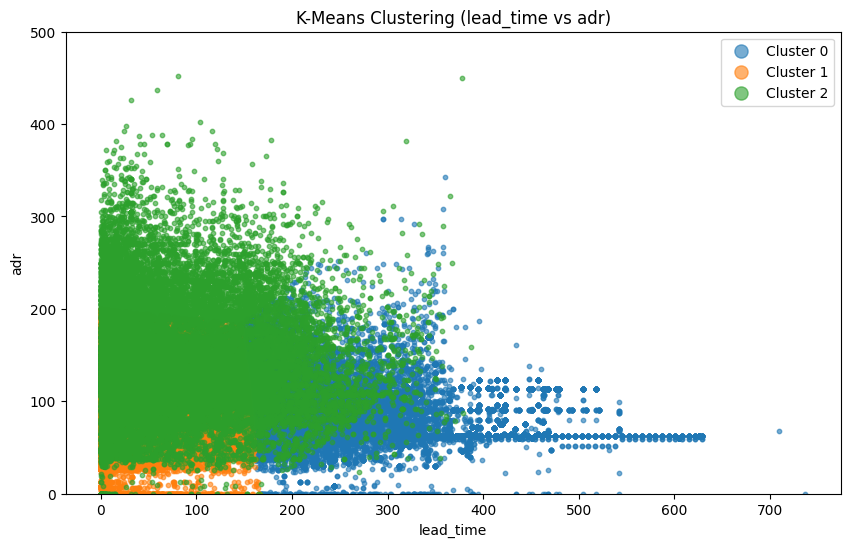

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df['cluster'] = kmeans.predict(X_scaled)
plt.figure(figsize=(10, 6))
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    plt.scatter(cluster_data['lead_time'], cluster_data['adr'], label=f'Cluster {cluster_id}', s=10, alpha=0.6)
plt.title('K-Means Clustering (lead_time vs adr)')
plt.xlabel('lead_time')
plt.ylabel('adr')
plt.ylim(0, 500)
plt.legend(markerscale=3)
plt.show()

### ✍️ Your Response: 🔧

1. I chose a `k` value of 3 for the K-Means clustering based on the initial exploration and the prompt's suggestion to choose a value between 3 and 5. This provides a reasonable number of segments to start interpreting.
2. From the scatter plot, the clusters appear to show potential groupings based on:
    * **Cluster 0:** Guests with very high lead times, suggesting they book far in advance, and generally lower ADRs. These could be early-bird bargain hunters.
    * **Cluster 1:** Guests with low lead times (booking closer to arrival) and a wide range of ADRs, but generally lower special requests. These might be last-minute or more spontaneous bookers.
    * **Cluster 2:** Guests with moderate to high ADRs and a higher number of special requests, with varying lead times. These could be guests seeking a more personalized or premium experience.

These are initial interpretations based on the two visualized features. Further analysis of the cluster characteristics across all selected features (`lead_time`, `adr`, and `total_of_special_requests`) would provide a clearer picture of each segment.

## 4. Apply Gaussian Mixture Model (GMM)

Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


,gmm_cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2
0,0,1.0,7.026551e-10,0.000000
1,0,1.0,3.561219e-15,0.000000
2,0,1.0,6.842885e-09,0.000000
3,0,1.0,6.870394e-09,0.000000
4,2,0.0,2.387199e-05,0.999976


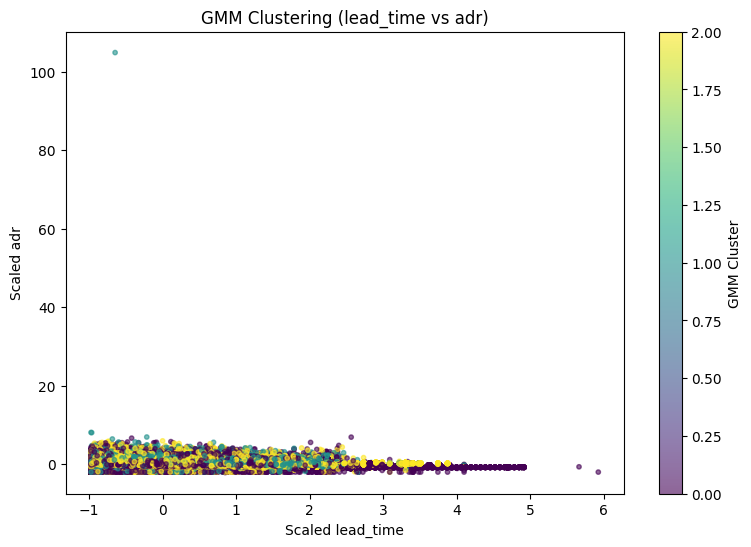

In [26]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)
probabilities = gmm.predict_proba(X_scaled)
df['gmm_cluster'] = gmm.predict(X_scaled)
for i in range(probabilities.shape[1]):
    df[f'prob_cluster_{i}'] = probabilities[:, i]
display(df[['gmm_cluster', 'prob_cluster_0', 'prob_cluster_1', 'prob_cluster_2']].head())
plt.figure(figsize=(9,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['gmm_cluster'], cmap='viridis', marker='o', s=10, alpha=0.6)
plt.title('GMM Clustering (lead_time vs adr)')
plt.xlabel('Scaled lead_time')
plt.ylabel('Scaled adr')
plt.colorbar(label='GMM Cluster')
plt.show()

### ✍️ Your Response: 🔧
1. The K-Means clustering produced distinct, well-separated groups based on booking lead time and room rates (ADR), creating clearer boundaries between customer types. In contrast, the GMM model shows more overlap and smoother transitions between clusters, capturing uncertainty where guests share similar behaviors. While K-Means forces each guest into one group, GMM recognizes that some guests fall between segments useful for marketing campaigns that target overlapping behaviors, such as guests who sometimes book early but pay premium rates. Overall, K-Means provides cleaner separation, but GMM delivers a more flexible, probabilistic understanding of customer patterns.

2. GMM could help answer questions like: “Which guests are most likely to switch from standard to premium bookings?” or “What is the probability that a guest belongs to more than one customer type?” It’s ideal for understanding blended behaviors, for example, guests who sometimes book early and last-minute, allowing the hotel to target overlapping segments with more flexible, data-driven marketing strategies.


## 5. Evaluate Your Models

Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

- Calculate:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index
- Compare both models

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

wcss = kmeans.inertia_
print(f"KMeans WCSS: {wcss:.2f}")
silhouette_kmeans = silhouette_score(X_scaled, df['cluster'])
print(f"KMeans Silhouette Score: {silhouette_kmeans:.4f}")
db_kmeans = davies_bouldin_score(X_scaled, df['cluster'])
print(f"KMeans Davies-Bouldin Index: {db_kmeans:.4f}")
silhouette_gmm = silhouette_score(X_scaled, df['gmm_cluster'])
print(f"GMM Silhouette Score: {silhouette_gmm:.4f}")
db_gmm = davies_bouldin_score(X_scaled, df['gmm_cluster'])
print(f"GMM Davies-Bouldin Index: {db_gmm:.4f}")

KMeans WCSS: 192661.91
KMeans Silhouette Score: 0.3322
KMeans Davies-Bouldin Index: 1.1243
GMM Silhouette Score: 0.2433
GMM Davies-Bouldin Index: 1.7072


### ✍️ Your Response: 🔧
1. based on the results, the KMeans model performed the best on the metrics

2. For a business analyst, K-Means is generally the better choice. It’s simpler, faster, and easier to interpret, making it ideal for business decisions and presentations. K-Means provides clear, distinct customer groups that can be easily labeled and acted upon for marketing or operational strategies. GMM, while more flexible, is mathematically complex and better suited for advanced analytics where probability-based or overlapping segments matter. In short, K-Means is more practical for clear communication and actionable insights, while GMM is better for deeper statistical modeling.


## 6. Business Interpretation

Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

- Review characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Think from a marketing or hotel operations perspective

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [31]:
# Summarize the key characteristics of each cluster
cluster_summary = df.groupby('cluster')[['lead_time', 'adr', 'total_of_special_requests']].mean()

# Add count of guests per cluster for context
cluster_summary['guest_count'] = df['cluster'].value_counts()

print("K-Means Cluster Characteristics:")
display(cluster_summary)

K-Means Cluster Characteristics:


,lead_time,adr,total_of_special_requests,guest_count
cluster,,,,
0,263.897931,90.591092,0.234669,26433
1,49.036136,85.713105,0.226327,60881
2,76.597456,141.686112,1.503710,32076


### ✍️ Your Response: 🔧
1. Cluster 0 represents early planners who book well in advance, spend moderately, and make few special requests, likely organized travelers or repeat guests. Cluster 1 includes last-minute or budget-conscious guests with short lead times and low spending, likely looking for affordable stays. Cluster 2 stands out as high-value guests with higher ADRs and more special requests, suggesting families or premium travelers seeking a personalized experience.

2. The hotel could offer early-booking discounts or loyalty rewards to Cluster 0 to encourage repeat business. Cluster 1 would respond well to last-minute deals or limited-time offers to fill vacant rooms quickly. For Cluster 2, the hotel could focus on premium service packages, upgrades, or family-oriented amenities to enhance satisfaction and increase revenue.


## 7. Final Reflection

Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The biggest challenge was interpreting the results, as there were no labels or predefined outcomes to guide us. It demanded critical thinking to ascertain what each cluster signified within a business context and to verify that the groupings were practically meaningful.

2. Clustering is best used when you don’t have labeled data or specific outcomes to predict, such as customer segmentation, behavior analysis, or identifying patterns in large, unstructured datasets.

3. Clustering enables a business to uncover inherent groupings within its data, such as distinguishing various types of guests or shoppers. This allows the company to more effectively customize services, pricing, and marketing strategies for each distinct group.

4. This directly contributes to my goal of enhancing data interpretation and business decision-making abilities. Through the application of unsupervised learning, I discovered how to convert raw data into actionable insights that align with strategic business objectives and customer-centric operations.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [37]:
!jupyter nbconvert --to html "assignment_09_LastnameFirstname.ipynb"

[NbConvertApp] Converting notebook assignment_09_LastnameFirstname.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 619360 bytes to assignment_09_LastnameFirstname.html
